## Analyzing Coffee Shop Sales
#### Dataset reference (Kaggle): https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales?resource=download  Author Name: Maven Analytics 
#### Transaction records for Maven Roasters, a fictitious coffee shop operating out of three NYC locations. Dataset includes the transaction date, timestamp and location, along with product-level details.


Objectives: 

- Sales trended over time? 
- Busiest days of the week? 
- Most sold product? Least sold product? Product drives most revenue? 



In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt 


In [2]:
df = pd.read_excel('Coffee Shop Sales.xlsx')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [3]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [5]:
df.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [6]:
df.duplicated().any()

False

In [7]:
col_vals = df.nunique().reset_index()
col_vals.rename(columns= {"index": "Column _name", 0: "Unique values"}, inplace=True)
col_vals

,Column _name,Unique values
0,transaction_id,149116
1,transaction_date,181
2,transaction_time,25762
3,transaction_qty,6
4,store_id,3
5,store_location,3
6,product_id,80
7,unit_price,41
8,product_category,9
9,product_type,29


In [8]:
df.describe(include=object)

,transaction_time,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,25762,3,9,29,80
top,09:31:15,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,41,50735,58416,17183,3076


In [9]:
drop_col = ['transaction_id', 'store_id', 'product_id']
df = df.drop(drop_col, axis=1).dropna()
df.head()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,product_detail
0,2023-01-01,07:06:11,2,Lower Manhattan,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2023-01-01,07:08:56,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,2023-01-01,07:14:04,2,Lower Manhattan,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,2023-01-01,07:20:24,1,Lower Manhattan,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,2023-01-01,07:22:41,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [10]:
date = df['transaction_date'].unique()[:25]
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month_name()
df['day'] = df['transaction_date'].dt.day_name()

df.head()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,product_detail,year,month,day
0,2023-01-01,07:06:11,2,Lower Manhattan,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023,January,Sunday
1,2023-01-01,07:08:56,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday
2,2023-01-01,07:14:04,2,Lower Manhattan,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023,January,Sunday
3,2023-01-01,07:20:24,1,Lower Manhattan,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023,January,Sunday
4,2023-01-01,07:22:41,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday


In [11]:
df['month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [12]:
df['day'].unique()

array(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday',
       'Saturday'], dtype=object)

In [13]:
df['Sales'] = df['transaction_qty'] * df['unit_price']
df.head()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,product_detail,year,month,day,Sales
0,2023-01-01,07:06:11,2,Lower Manhattan,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023,January,Sunday,6.0
1,2023-01-01,07:08:56,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday,6.2
2,2023-01-01,07:14:04,2,Lower Manhattan,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023,January,Sunday,9.0
3,2023-01-01,07:20:24,1,Lower Manhattan,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023,January,Sunday,2.0
4,2023-01-01,07:22:41,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday,6.2


AttributeError: module 'matplotlib' has no attribute 'show'

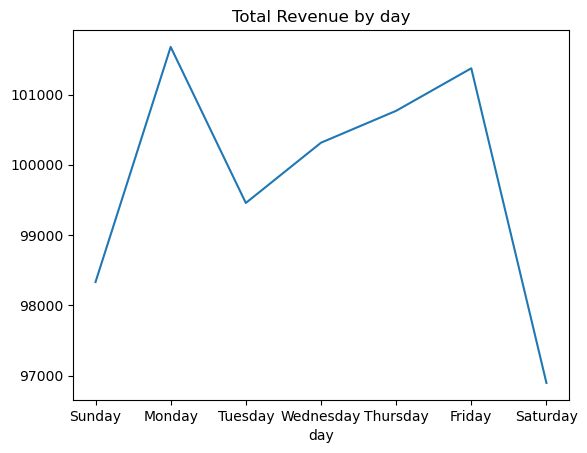

In [14]:
# bar plot showcasing sales on each day.
import seaborn as sns 
import matplotlib as plt

sales_by_day = df.groupby('day')['Sales'].sum().reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
sales_by_day.plot(kind='line', title='Total Revenue by day')
plt.show()

plt.savefig('sales_by_day_bar.png')


In [15]:
sales_by_day

day
Sunday        98330.31
Monday       101677.28
Tuesday       99455.94
Wednesday    100313.54
Thursday     100767.78
Friday       101373.00
Saturday      96894.48
Name: Sales, dtype: float64

In [16]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['Hour'] = df['transaction_time'].dt.hour
df['Minute']= df['transaction_time'].dt.minute
df.head()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,product_detail,year,month,day,Sales,Hour,Minute
0,2023-01-01,1900-01-01 07:06:11,2,Lower Manhattan,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023,January,Sunday,6.0,7,6
1,2023-01-01,1900-01-01 07:08:56,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday,6.2,7,8
2,2023-01-01,1900-01-01 07:14:04,2,Lower Manhattan,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023,January,Sunday,9.0,7,14
3,2023-01-01,1900-01-01 07:20:24,1,Lower Manhattan,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023,January,Sunday,2.0,7,20
4,2023-01-01,1900-01-01 07:22:41,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday,6.2,7,22


AttributeError: module 'matplotlib' has no attribute 'xlabel'

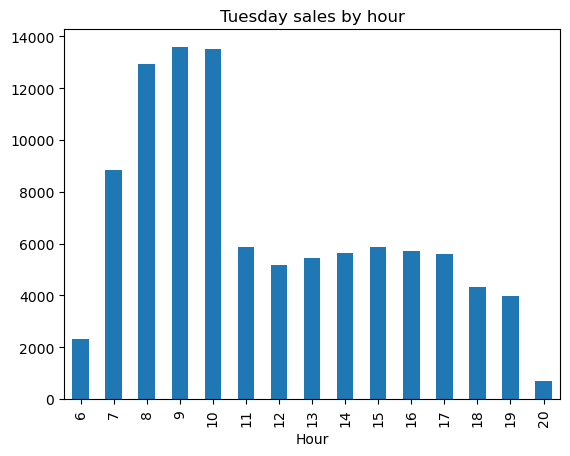

In [18]:
tuesday = day_hour_sales['Tuesday']
g2 = tuesday.plot(kind='bar', title='Tuesday sales by hour')
plt.xlabel('Hour')
plt.ylabel('Sales')
plt.show()

AttributeError: 'Axes' object has no attribute 'xlabel'

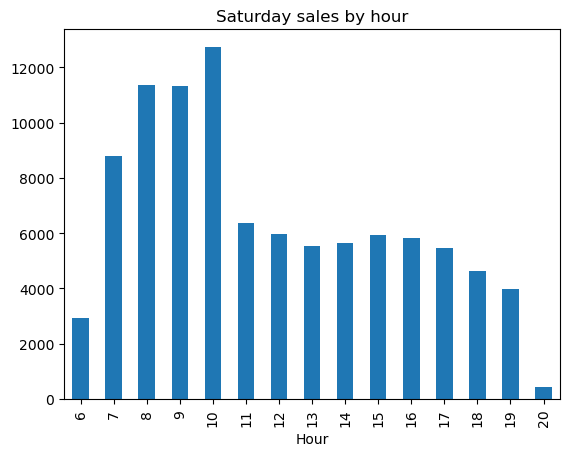

In [19]:
saturday = day_hour_sales['Saturday']
g3 = saturday.plot(kind='bar', title='Saturday sales by hour')
g3.xlabel('Hour')
g3.ylabel('Sales')
g3.show()

AttributeError: 'Axes' object has no attribute 'xlabel'

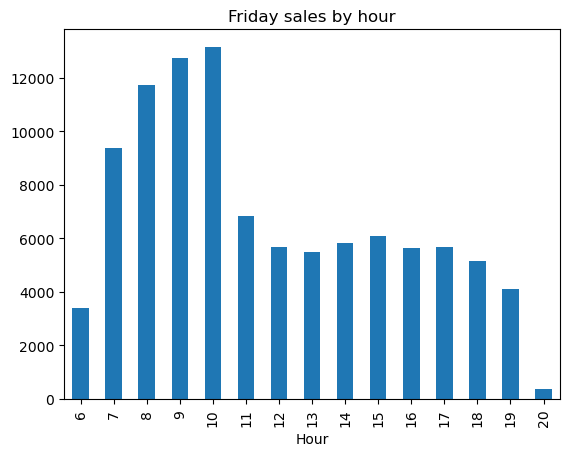

In [20]:
Friday = day_hour_sales['Friday']
g3 = Friday.plot(kind='bar', title='Friday sales by hour')
g3.xlabel('Hour')
g3.ylabel('Sales')
g3.show()

AttributeError: 'Axes' object has no attribute 'xlabel'

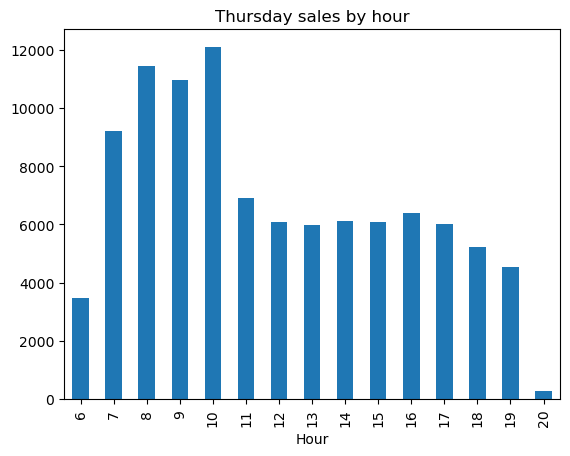

In [21]:
Thursday = day_hour_sales['Thursday']
g3 = Thursday.plot(kind='bar', title='Thursday sales by hour')
g3.xlabel('Hour')
g3.ylabel('Sales')
g3.show()

AttributeError: module 'matplotlib' has no attribute 'xlabel'

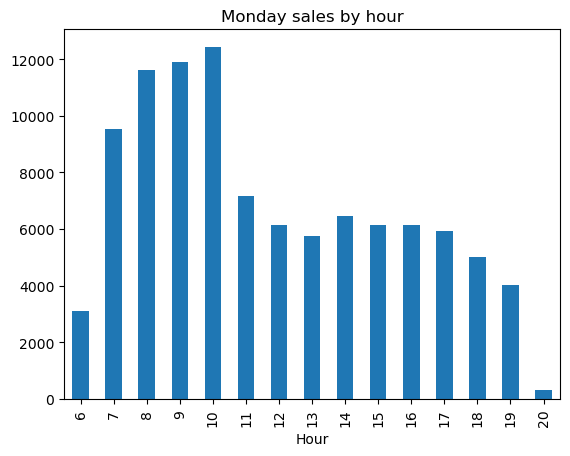

In [23]:
df['Hour'].unique()

day_hour_sales = df.groupby(['day','Hour'])['Sales'].sum()
monday = day_hour_sales['Monday']
g1 = monday.plot(kind='bar', title='Monday sales by hour')
plt.xlabel('Hour')
plt.ylabel('Sales')
plt.show()

#### Analysis:  <br> 

###### 1 - How have Maven Roasters sales trended over time? <br> 
###### 2 - Which days of the week tend to be busiest, and why do you think that's the case?


#### Busiest days of the week

The data shows that the peak are Mondays and Fridays. In contrast, weekends has the loweset sales of the week. Other days like Wednesdays, Thursdays are about average. 

#### Busiest Times of the Day

Sales are most concentrated during the morning hours, specifically between 7 a.m. and 10 a.m. This period accounts for the highest volume of transactions each day.

The daily sales trends appear to be strongly correlated with consumer commuting habits. The high sales on Mondays likely reflect customers buying coffee on their way to work at the beginning of the new week. Similarly, the high traffic on Fridays suggests a pattern of customers grabbing a coffee at the end of the work week.

In [24]:
df.head()
df['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [25]:
df.head()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,product_detail,year,month,day,Sales,Hour,Minute
0,2023-01-01,1900-01-01 07:06:11,2,Lower Manhattan,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023,January,Sunday,6.0,7,6
1,2023-01-01,1900-01-01 07:08:56,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday,6.2,7,8
2,2023-01-01,1900-01-01 07:14:04,2,Lower Manhattan,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023,January,Sunday,9.0,7,14
3,2023-01-01,1900-01-01 07:20:24,1,Lower Manhattan,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023,January,Sunday,2.0,7,20
4,2023-01-01,1900-01-01 07:22:41,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023,January,Sunday,6.2,7,22


In [26]:
products_price = df[['transaction_qty', 'unit_price', 'product_type', 'product_category', 'Sales', 'day', 'Hour']]
products_price.head()

products_price = products_price.replace({"day":{ "Sunday":1, "Monday":2, "Tuesday":3, "Wednesday":4, "Thursday":5, "Friday":6, "Saturday":7} })
products_price.head()

,transaction_qty,unit_price,product_type,product_category,Sales,day,Hour
0,2,3.0,Gourmet brewed coffee,Coffee,6.0,1,7
1,2,3.1,Brewed Chai tea,Tea,6.2,1,7
2,2,4.5,Hot chocolate,Drinking Chocolate,9.0,1,7
3,1,2.0,Drip coffee,Coffee,2.0,1,7
4,2,3.1,Brewed Chai tea,Tea,6.2,1,7


AttributeError: module 'matplotlib' has no attribute 'show'

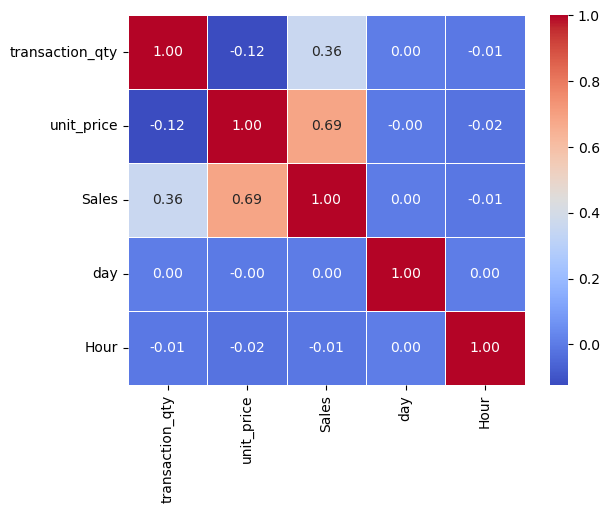

In [27]:
import matplotlib as plt
import seaborn as sns 
# qty = products_price['transaction_qty']
# each_price = products_price['unit_price']
# prod_type = products_price['product_type']
# prod_cate = products_price['product_category']
# each_sales = products_price['Sales']

table = pd.DataFrame(products_price)
num_df = table[['transaction_qty', 'unit_price', 'Sales', 'day', 'Hour']]
corr_mat = num_df.corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [28]:
df['store_location'].unique()

array(['Lower Manhattan', "Hell's Kitchen", 'Astoria'], dtype=object)

AttributeError: 'Axes' object has no attribute 'xlabel'

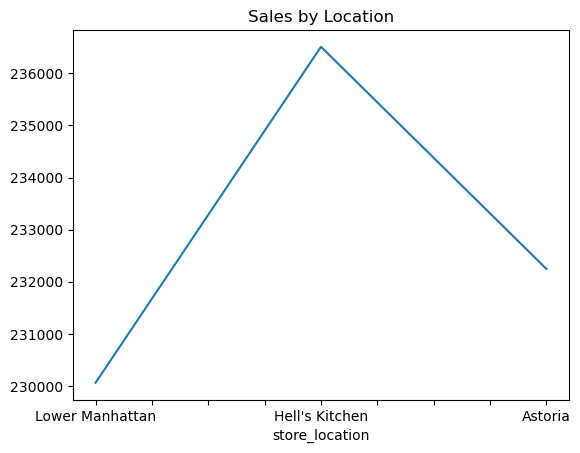

In [29]:
# sales by location : store_location, Sales

sales_by_location = df.groupby('store_location')['Sales'].sum().reindex(["Lower Manhattan", "Hell's Kitchen", "Astoria"])
sales_by_location.head()
g4 = sales_by_location.plot(kind='line', title='Sales by Location')
g4.xlabel('Location')
g4.ylabel('Sales')
g4.show()

In [30]:
# average time between sales of a product
products_price = products_price.replace({"day":{ 1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday", 7: "Saturday"} })
products_price.head()
# day, hour, product, quantity, sales
print(Friday.head())
sales_prod = products_price.groupby(['day', 'Hour'])[['transaction_qty', 'unit_price', 'product_type', 'product_category', 'Sales']].sum()
sales_prod

Hour
6      3385.73
7      9386.04
8     11746.65
9     12750.00
10    13155.66
Name: Sales, dtype: float64


transaction_qty  unit_price  \
day       Hour                                
Friday    6                1058     2374.33   
          7                2884     6798.39   
          8                3641     8543.00   
          9                3847     9408.55   
          10               3997     9574.41   
...                         ...         ...   
Wednesday 16               1779     4171.91   
          17               1794     3991.35   
          18               1635     3669.15   
          19               1173     2822.40   
          20                116      337.58   

                                                     product_type  \
day       Hour                                                      
Friday    6     Drip coffeeBrewed Black teaHot chocolateHot ch...   
          7     Brewed Chai teaSconeBrewed herbal teaBarista E...   
          8     Organic brewed coffeeBrewed Chai teaBiscottiBa...   
          9     Brewed herbal teaHot chocolatePremium brewed c...   
          10    Brewed Black teaOrganic brewed coffeeOrganic b...   
...                                                           ...   
Wednesday 16    Drip coffeeSconeHot chocolatePremium brewed co...   
          17    Gourmet brewed coffeeBiscottiDrip coffeeBrewed...   
          18    Organic brewed coffeeBrewed Green teaBrewed Gr...   
          19    Barista EspressoBiscottiOrganic brewed coffeeB...   
          20    Brewed herbal teaPremium brewed coffeeBrewed G...   

                                                 product_category     Sales  
day       Hour                                                               
Friday    6     CoffeeTeaDrinking ChocolateDrinking ChocolateB...   3385.73  
          7     TeaBakeryTeaCoffeeBakeryTeaTeaTeaTeaDrinking C...   9386.04  
          8     CoffeeTeaBakeryCoffeeTeaCoffeeTeaCoffeeCoffeeT...  11746.65  
          9     TeaDrinking ChocolateCoffeeCoffeeCoffeeDrinkin...  12750.00  
          10    TeaCoffeeCoffeeCoffeeTeaCoffeeDrinking Chocola...  13155.66  
...                                                           ...       ...  
Wednesday 16    CoffeeBakeryDrinking ChocolateCoffeeCoffeeDrin...   5649.76  
          17    CoffeeBakeryCoffeeTeaCoffeeBakeryCoffeeTeaTeaC...   5649.55  
          18    CoffeeTeaTeaTeaBakeryCoffeeTeaCoffeeCoffeeBake...   5166.35  
          19    CoffeeBakeryCoffeeTeaCoffeeCoffeeDrinking Choc...   3828.55  
          20    TeaCoffeeTeaCoffeeCoffeeTeaCoffeeTeaTeaTeaBake...    430.83  

[105 rows x 5 columns]

In [31]:
print(monday.head())
mon_trans = products_price[(products_price['day'] == 'Monday') & (products_price['Hour'] >= 7) & (products_price['Hour'] <= 10)] 
# # Debug: 
#print(f"Number of Monday transactions: {len(mon_trans)}")
#print(mon_trans.head())

#mon_trans['product_type'].unique()
prods = mon_trans['product_type'].value_counts().to_dict()

total_sales_by_product = mon_trans.groupby('product_type')['Sales'].sum()
mon_prod_sales = total_sales_by_product.to_dict()

print("Products sold Monday from 7am to 10am: ")        
for k, v in prods.items():
    print(k, ": ", v) 

print("\n")
print("Total sales for each product on Monday (7-10 AM):")
for product, total_sales in mon_prod_sales.items():
    print(f"{product}: ${total_sales:.2f}")


Hour
6      3098.58
7      9516.52
8     11604.69
9     11898.33
10    12427.25
Name: Sales, dtype: float64
Products sold Monday from 7am to 10am: 
Brewed Chai tea :  1065
Gourmet brewed coffee :  1023
Barista Espresso :  997
Brewed herbal tea :  711
Brewed Black tea :  709
Hot chocolate :  708
Scone :  701
Pastry :  546
Drip coffee :  542
Premium brewed coffee :  537
Organic brewed coffee :  503
Biscotti :  383
Regular syrup :  375
Brewed Green tea :  332
Sugar free syrup :  138
Organic Beans :  39
Housewares :  37
Gourmet Beans :  33
Chai tea :  32
Premium Beans :  30
Espresso Beans :  24
Herbal tea :  22
Organic Chocolate :  18
Black tea :  16
Clothing :  14
Drinking Chocolate :  13
House blend Beans :  13
Green tea :  13
Green beans :  6


Total sales for each product on Monday (7-10 AM):
Barista Espresso: $5471.15
Biscotti: $1319.70
Black tea: $143.20
Brewed Black tea: $3017.00
Brewed Chai tea: $4793.20
Brewed Green tea: $1399.50
Brewed herbal tea: $3045.50
Chai tea: $311.20
Cloth

AttributeError: 'Axes' object has no attribute 'xlabel'

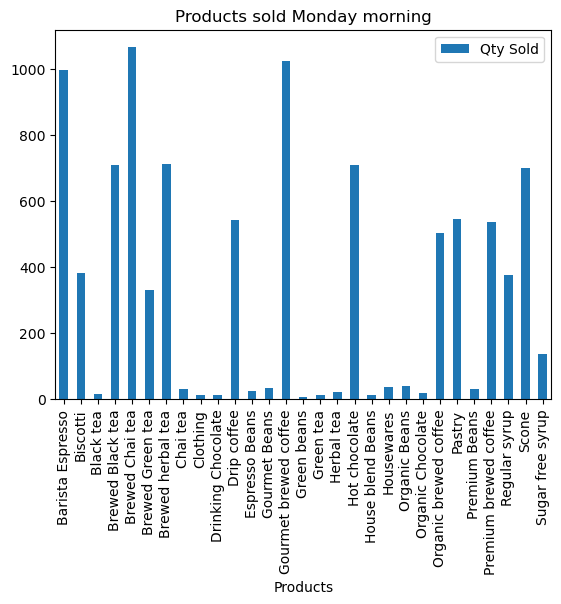

In [32]:
monday_table = pd.DataFrame({'Products': list(prods.keys()), 'Qty Sold': list(prods.values())})
monday_table.head()
monday_table_1 = monday_table.groupby('Products')[['Qty Sold']].sum()
monday_table_1.head()
g5 = monday_table_1.plot(kind='bar', title='Products sold Monday morning')
g5.xlabel('Products')
g5.ylabel('Qty sold')
g5.show()

AttributeError: 'Axes' object has no attribute 'show'

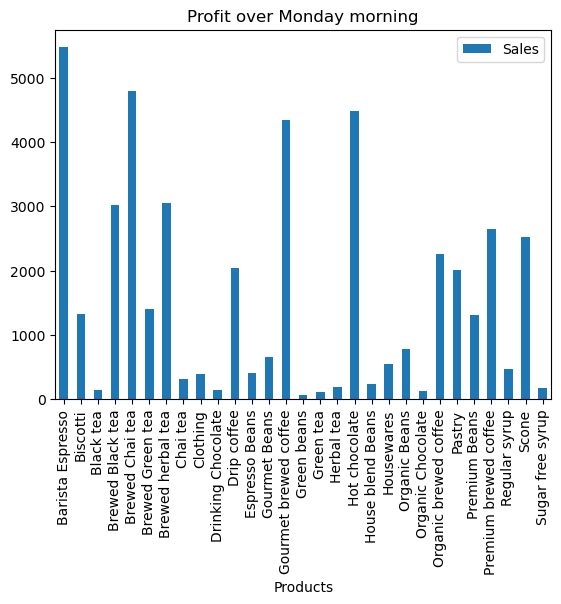

In [33]:
mon_sales_profit = pd.DataFrame({'Products':list(mon_prod_sales.keys()), 'Sales':list(mon_prod_sales.values())})
#mon_sales_profit.head()
tab = mon_sales_profit.groupby('Products')[['Sales']].sum()
g6 = tab.plot(kind='bar', title='Profit over Monday morning')
g6.show()

To continue the trend to see if we get similar products, we can see Friday and Saturday.

In [34]:
# Fridays: Hour 7 - 10
#friday.head()
fri_trans = products_price[(products_price['day'] == 'Friday') & (products_price['Hour'] >= 7) & (products_price['Hour'] <= 10)] 
# print(len(fri_trans))
fri_trans

f_prods = fri_trans['product_type'].value_counts().to_dict()

print("Quantity of Products sold Friday from 7am to 10am: ")        
for k, v in f_prods.items():
    print(k, ": ", v) 

print("\n")

fri_total_sales_by_product = fri_trans.groupby('product_type')['Sales'].sum()
fri_prod_sales = fri_total_sales_by_product.to_dict()

print("Total sales for each product on Friday (7-10 AM):")
for product, total_sales in fri_prod_sales.items():
    print(f"{product}: ${total_sales:.2f}")


Quantity of Products sold Friday from 7am to 10am: 
Brewed Chai tea :  1104
Barista Espresso :  1102
Gourmet brewed coffee :  1053
Brewed Black tea :  729
Scone :  715
Brewed herbal tea :  705
Hot chocolate :  685
Organic brewed coffee :  574
Drip coffee :  552
Pastry :  534
Regular syrup :  496
Premium brewed coffee :  481
Biscotti :  402
Brewed Green tea :  377
Sugar free syrup :  140
Housewares :  41
Chai tea :  34
Organic Beans :  32
Gourmet Beans :  32
Espresso Beans :  31
Premium Beans :  30
Herbal tea :  26
Black tea :  26
Drinking Chocolate :  24
Organic Chocolate :  18
House blend Beans :  18
Green tea :  17
Clothing :  14
Green beans :  9


Total sales for each product on Friday (7-10 AM):
Barista Espresso: $6216.85
Biscotti: $1391.33
Black tea: $232.70
Brewed Black tea: $3110.00
Brewed Chai tea: $5010.00
Brewed Green tea: $1584.00
Brewed herbal tea: $3075.50
Chai tea: $328.90
Clothing: $392.00
Drinking Chocolate: $257.55
Drip coffee: $2116.50
Espresso Beans: $525.65
Gourmet 

AttributeError: 'Axes' object has no attribute 'show'

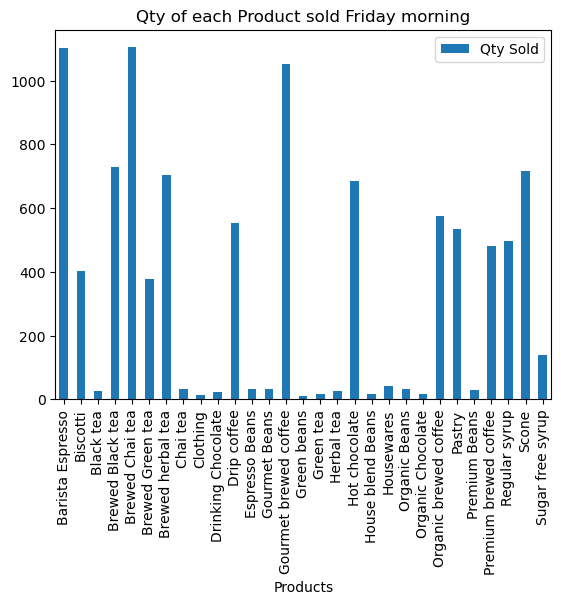

In [35]:
# f_prods

fri_table1 = pd.DataFrame({'Products':list(f_prods.keys()), 'Qty Sold':list(f_prods.values())})
fri_table1.head()
fri_table2 = fri_table1.groupby('Products')[['Qty Sold']].sum()
g6 = fri_table2.plot(kind='bar',title='Qty of each Product sold Friday morning')
g6.show()


AttributeError: 'Axes' object has no attribute 'show'

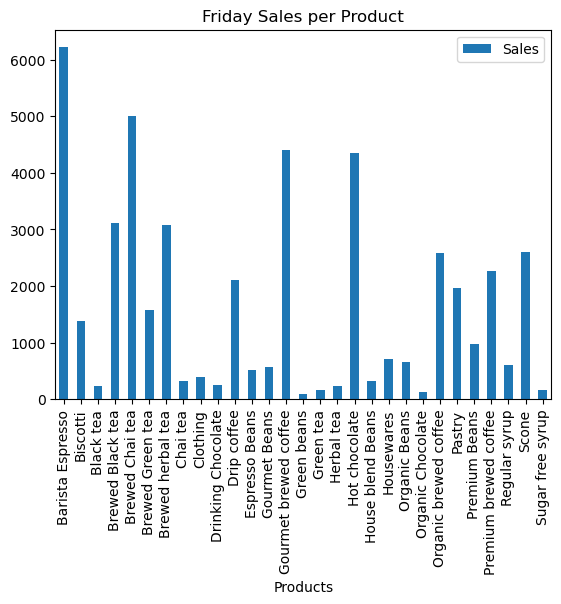

In [36]:
# fri_prod_sales
fri_table3 = pd.DataFrame({'Products':list(fri_prod_sales.keys()), 'Sales':list(fri_prod_sales.values())})
table4 = fri_table3.groupby('Products')[['Sales']].sum()
g7 = table4.plot(kind='bar', title='Friday Sales per Product')
g7.show()

In [37]:
# Saturdays (busiest hours: 7-10am)
sat_trans = products_price[(products_price['day'] == 'Saturday') & (products_price['Hour'] >= 7) & (products_price['Hour'] <= 10)] 
# print(len(fri_trans))

s_prods = sat_trans['product_type'].value_counts().to_dict()

print("Quantity of Products sold Saturday from 7am to 10am: ")        
for k, v in s_prods.items():
    print(k, ": ", v) 

print("\n")

sat_total_sales_by_product = sat_trans.groupby('product_type')['Sales'].sum()
sat_prod_sales = sat_total_sales_by_product.to_dict()

print("Total sales for each product on Saturday (7-10 AM):")
for product, total_sales in sat_prod_sales.items():
    print(f"{product}: ${total_sales:.2f}")


Quantity of Products sold Saturday from 7am to 10am: 
Brewed Chai tea :  1005
Barista Espresso :  1004
Gourmet brewed coffee :  969
Brewed Black tea :  660
Brewed herbal tea :  657
Scone :  647
Hot chocolate :  640
Pastry :  526
Organic brewed coffee :  509
Premium brewed coffee :  494
Drip coffee :  476
Regular syrup :  448
Biscotti :  350
Brewed Green tea :  343
Sugar free syrup :  153
Housewares :  40
Organic Beans :  40
Espresso Beans :  34
Chai tea :  31
Premium Beans :  29
Gourmet Beans :  26
Herbal tea :  24
Clothing :  20
Black tea :  20
Organic Chocolate :  16
Drinking Chocolate :  14
House blend Beans :  14
Green tea :  13
Green beans :  9


Total sales for each product on Saturday (7-10 AM):
Barista Espresso: $5715.80
Biscotti: $1201.25
Black tea: $179.00
Brewed Black tea: $2796.00
Brewed Chai tea: $4600.15
Brewed Green tea: $1440.50
Brewed herbal tea: $2759.50
Chai tea: $295.15
Clothing: $560.00
Drinking Chocolate: $138.11
Drip coffee: $1807.00
Espresso Beans: $609.80
Gourm

AttributeError: 'Axes' object has no attribute 'show'

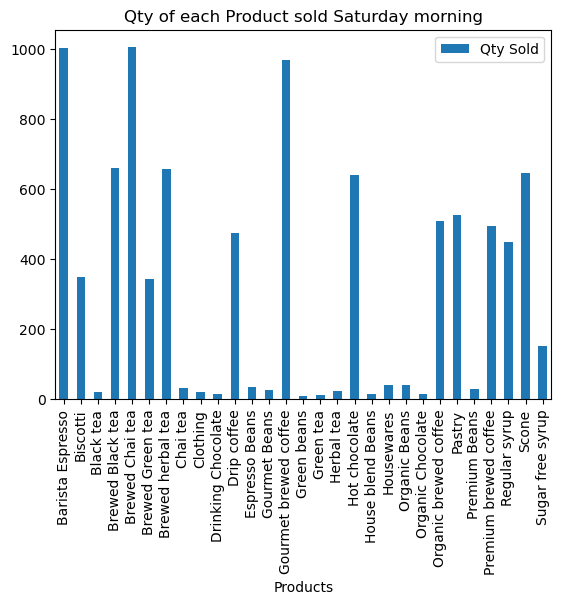

In [38]:
sat_table1 = pd.DataFrame({'Products':list(s_prods.keys()), 'Qty Sold':list(s_prods.values())})
sat_table2 = sat_table1.groupby('Products')[['Qty Sold']].sum()
g8 = sat_table2.plot(kind='bar',title='Qty of each Product sold Saturday morning')
g8.show()


AttributeError: 'Axes' object has no attribute 'show'

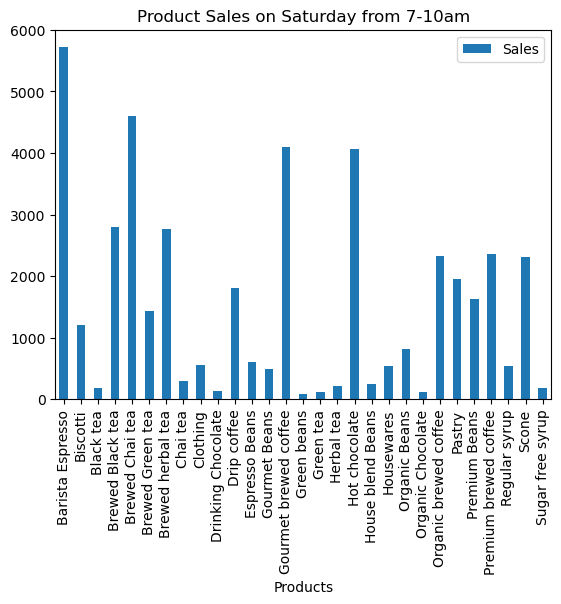

In [39]:
sat_table3 = pd.DataFrame({'Products':list(sat_prod_sales.keys()), 'Sales':list(sat_prod_sales.values())})
sat_table4 = sat_table3.groupby('Products')[['Sales']].sum()
g9 = sat_table4.plot(kind='bar', title='Product Sales on Saturday from 7-10am')
g9.show()

#### Product Popularity & Profitability 

**Monday Morning Product Trends** <br> 
During the busiest morning hours on Mondays, the most popular products are:

- Brewed Chai Tea: This product has the highest sales volume.
- Barista Espresso: While not the highest in volume, it generates the most profit.
- Brewed Coffee and Herbal Tea: These are also top-selling beverages.
- Hot Chocolate: This is a frequently ordered item, particularly on cooler days.

The least popular product is Green Beans, which are sold in very low quantities.





**Friday Product Trends** <br> 
Fridays show a similar trend in product popularity. The top five most ordered products are: 

- Brewed Chai Tea
- Barista Espresso
- Brewed Coffee
- Brewed Black Tea
- Scone

**Profitability**: The most profitable products on Fridays are consistent with Monday's findings: Barista Espresso, Chai Tea, Brewed Coffee, and Hot Chocolate.

Similar to Mondays, Green Beans are the least sold and least profitable product on Fridays.



**Conclusion**

Based on the sales data from Jan - Jun 2023, the following is drawn:
- **Busiest days and times:** Mondays, Fridays are busiest with peak hours from 7am -10am. Saturday remains least popular day. 
- **Most Popular & Profitable Products:** Barista Espresso, Brewed Coffee, and Chai Tea are the key drivers of both sales volume and profitability.
- **Seasonal / Demographic Influences:** Hot chocolate are notably frequent, especially on winter (or sometimes even spring) days and among customers like children who may not prefer coffee or tea. 
- **Food Item Popularity:** Scone is popular food pairing, while non-beverage products like Green beans are not commonly purchased at coffee shops. 
